# Bootstrap sobre test - Análisis de sentimiento parlamentario

Notebook para calcular intervalos de confianza del F1 macro mediante bootstrap con reemplazo, y comparar configuraciones mediante bootstrap pareado.

**Estructura esperada de los archivos Excel:**
- Una fila por intervención de test
- Columnas mínimas: `id_intervencion`, `true_label`, `pred_label`
- Columna opcional: `pred_label_sw` (para sliding window)

**Nomenclatura recomendada de archivos:**
- `rouberta_simple_2050.xlsx`
- `rouberta_simple_1899.xlsx`
- `robertuito_sliding_mean_2050.xlsx`
- etc.


## 1. Setup

In [ ]:
!pip install -q scikit-learn numpy pandas matplotlib openpyxl

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report, precision_score, recall_score
from itertools import combinations

## 2. Cargar archivos

Subí todos los Excel de predicciones al mismo tiempo (Ctrl+click o Shift+click para seleccionar varios).

In [ ]:
from google.colab import files
uploaded = files.upload()

print(f"\nArchivos cargados: {len(uploaded)}")
for name in uploaded.keys():
    print(f"  - {name}")

Saving analisis_robertuito_base__slide_1405_mean.xlsx to analisis_robertuito_base__slide_1405_mean (1).xlsx
Saving analisis_robertuito_base__slide_1405_vote.xlsx to analisis_robertuito_base__slide_1405_vote (1).xlsx
Saving analisis_robertuito_base__slide_1899_mean.xlsx to analisis_robertuito_base__slide_1899_mean (1).xlsx
Saving analisis_robertuito_base__slide_1899_vote.xlsx to analisis_robertuito_base__slide_1899_vote (1).xlsx
Saving analisis_robertuito_base__slide_2050_mean.xlsx to analisis_robertuito_base__slide_2050_mean (2).xlsx
Saving analisis_robertuito_base__slide_2050_vote.xlsx to analisis_robertuito_base__slide_2050_vote (1).xlsx
Saving analisis_robertuito_base_1405.xlsx to analisis_robertuito_base_1405 (1).xlsx
Saving analisis_robertuito_base_1899.xlsx to analisis_robertuito_base_1899 (1).xlsx
Saving analisis_robertuito_base_2050.xlsx to analisis_robertuito_base_2050 (1).xlsx
Saving analisis_ROU_base_1405.xlsx to analisis_ROU_base_1405 (1).xlsx
Saving analisis_ROU_base_1899.

In [ ]:
# Diccionario: nombre_archivo -> DataFrame
modelos = {}

for filename in uploaded.keys():
    nombre = filename.replace('.xlsx', '').replace('.xls', '')
    df = pd.read_excel(filename)

    # Normalizar etiquetas a string sin espacios
    df['true_label'] = df['true_label'].astype(str).str.strip()
    df['pred_label'] = df['pred_label'].astype(str).str.strip()

    if 'pred_label_sw' in df.columns:
        df['pred_label_sw'] = df['pred_label_sw'].astype(str).str.strip()

    modelos[nombre] = df
    pred_cols = [c for c in df.columns if 'pred' in c.lower() or 'true' in c.lower()]
    print(f"{nombre}: {len(df)} filas, columnas relevantes = {pred_cols}")

analisis_robertuito_base__slide_1405_mean (1): 123 filas, columnas relevantes = ['true_label', 'pred_label', 'conf_pred', 'pred_label_sw']
analisis_robertuito_base__slide_1405_vote (1): 123 filas, columnas relevantes = ['true_label', 'pred_label', 'conf_pred', 'pred_label_sw']
analisis_robertuito_base__slide_1899_mean (1): 123 filas, columnas relevantes = ['true_label', 'pred_label', 'conf_pred', 'pred_label_sw']
analisis_robertuito_base__slide_1899_vote (1): 123 filas, columnas relevantes = ['true_label', 'pred_label', 'conf_pred', 'pred_label_sw']
analisis_robertuito_base__slide_2050_mean (2): 123 filas, columnas relevantes = ['true_label', 'pred_label', 'conf_pred', 'pred_label_sw']
analisis_robertuito_base__slide_2050_vote (1): 123 filas, columnas relevantes = ['true_label', 'pred_label', 'conf_pred', 'pred_label_sw']
analisis_robertuito_base_1405 (1): 123 filas, columnas relevantes = ['true_label', 'pred_label', 'conf_pred', 'pred_label_sw']
analisis_robertuito_base_1899 (1): 123 

## 3. Verificar coincidencia de IDs entre archivos

Para el bootstrap pareado es fundamental que todos los archivos evalúen las mismas 122 intervenciones.

In [ ]:
nombres = list(modelos.keys())

if len(nombres) > 1:
    ids_referencia = set(modelos[nombres[0]]['id_intervencion'])
    print(f"Archivo de referencia: {nombres[0]} ({len(ids_referencia)} ids)")
    print()

    for nombre in nombres[1:]:
        ids_actual = set(modelos[nombre]['id_intervencion'])
        diff = ids_referencia.symmetric_difference(ids_actual)
        if len(diff) == 0:
            print(f"OK {nombre}: ids idénticos")
        else:
            print(f"XX {nombre}: difiere en {len(diff)} ids")
else:
    print("Solo hay un archivo cargado. Las comparaciones pareadas requieren al menos 2.")

Archivo de referencia: analisis_robertuito_base__slide_1405_mean (1) (123 ids)

OK analisis_robertuito_base__slide_1405_vote (1): ids idénticos
XX analisis_robertuito_base__slide_1899_mean (1): difiere en 216 ids
XX analisis_robertuito_base__slide_1899_vote (1): difiere en 216 ids
XX analisis_robertuito_base__slide_2050_mean (2): difiere en 212 ids
XX analisis_robertuito_base__slide_2050_vote (1): difiere en 212 ids
OK analisis_robertuito_base_1405 (1): ids idénticos
XX analisis_robertuito_base_1899 (1): difiere en 216 ids
XX analisis_robertuito_base_2050 (1): difiere en 212 ids
OK analisis_ROU_base_1405 (1): ids idénticos
XX analisis_ROU_base_1899 (1): difiere en 216 ids
XX analisis_ROU_base_2050 (2): difiere en 212 ids
OK analisis_ROU_slide_1405_mean (1): ids idénticos
OK analisis_ROU_slide_1405_vote (1): ids idénticos
XX analisis_ROU_slide_1899_mean (1): difiere en 216 ids
XX analisis_ROU_slide_1899_vote (1): difiere en 216 ids
XX analisis_ROU_slide_2050_mean (1): difiere en 212 ids

## 4. Construir estructura unificada de predicciones

Cada combinación de (archivo, esquema de inferencia) se trata como una configuración independiente.

In [ ]:
# =========================================
# Celda 4 CORREGIDA: construir configs
# =========================================
configs = {}

for nombre, df in modelos.items():
    # NO ordenar por id_intervencion, usar el orden original del Excel
    # que es el orden del test set del entrenamiento
    df_work = df.copy()

    # Limpiar true_label y pred_label
    df_work['true_label'] = df_work['true_label'].astype(str).str.strip()
    df_work['pred_label'] = df_work['pred_label'].astype(str).str.strip()

    # Filtrar solo filas donde ambas columnas tienen valores válidos
    mask_simple = (
        df_work['true_label'].isin(['N', 'Neu', 'P']) &
        df_work['pred_label'].isin(['N', 'Neu', 'P'])
    )
    df_simple = df_work[mask_simple].copy()

    y_true_simple = df_simple['true_label'].values
    y_pred_simple = df_simple['pred_label'].values

    configs[f"{nombre}_simple"] = (y_true_simple, y_pred_simple)
    print(f"  {nombre}_simple: {len(df_simple)} filas")

    # Sliding window
    if 'pred_label_sw' in df_work.columns:
        df_work['pred_label_sw'] = df_work['pred_label_sw'].astype(str).str.strip()
        mask_sliding = (
            df_work['true_label'].isin(['N', 'Neu', 'P']) &
            df_work['pred_label_sw'].isin(['N', 'Neu', 'P'])
        )
        df_sliding = df_work[mask_sliding].copy()

        if len(df_sliding) >= len(df_work) * 0.9:
            y_true_sliding = df_sliding['true_label'].values
            y_pred_sliding = df_sliding['pred_label_sw'].values
            configs[f"{nombre}_sliding"] = (y_true_sliding, y_pred_sliding)
            print(f"  {nombre}_sliding: {len(df_sliding)} filas")

print(f"\nTotal configuraciones: {len(configs)}")

  analisis_robertuito_base__slide_1405_mean (1)_simple: 123 filas
  analisis_robertuito_base__slide_1405_mean (1)_sliding: 123 filas
  analisis_robertuito_base__slide_1405_vote (1)_simple: 123 filas
  analisis_robertuito_base__slide_1405_vote (1)_sliding: 123 filas
  analisis_robertuito_base__slide_1899_mean (1)_simple: 123 filas
  analisis_robertuito_base__slide_1899_mean (1)_sliding: 123 filas
  analisis_robertuito_base__slide_1899_vote (1)_simple: 123 filas
  analisis_robertuito_base__slide_1899_vote (1)_sliding: 123 filas
  analisis_robertuito_base__slide_2050_mean (2)_simple: 123 filas
  analisis_robertuito_base__slide_2050_mean (2)_sliding: 123 filas
  analisis_robertuito_base__slide_2050_vote (1)_simple: 123 filas
  analisis_robertuito_base__slide_2050_vote (1)_sliding: 123 filas
  analisis_robertuito_base_1405 (1)_simple: 123 filas
  analisis_robertuito_base_1899 (1)_simple: 123 filas
  analisis_robertuito_base_2050 (1)_simple: 123 filas
  analisis_ROU_base_1405 (1)_simple: 123

## 5. Bootstrap básico - F1 macro con IC 95% por configuración

In [ ]:
def bootstrap_f1(y_true, y_pred, n_iterations=1000, seed=1899):
    """
    Bootstrap con reemplazo del F1 macro.
    Devuelve diccionario con: f1 puntual, media, std, IC 95%, array de scores.
    """
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)

    scores = []
    for _ in range(n_iterations):
        idx = rng.integers(0, n, size=n)
        score = f1_score(y_true[idx], y_pred[idx], average='macro', zero_division=0)
        scores.append(score)

    scores = np.array(scores)
    return {
        'f1_point': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_mean': scores.mean(),
        'f1_std': scores.std(),
        'ci_low': np.percentile(scores, 2.5),
        'ci_high': np.percentile(scores, 97.5),
        'scores': scores
    }

In [ ]:
resultados = {}

print(f"{'Configuración':<55} {'F1 punt':<10} {'F1 media':<10} {'IC 95%':<22}")
print("-" * 100)

for nombre, (y_true, y_pred) in configs.items():
    res = bootstrap_f1(y_true, y_pred)
    resultados[nombre] = res
    print(f"{nombre:<55} {res['f1_point']:.4f}     {res['f1_mean']:.4f}     [{res['ci_low']:.3f}, {res['ci_high']:.3f}]")

Configuración                                           F1 punt    F1 media   IC 95%                
----------------------------------------------------------------------------------------------------
analisis_robertuito_base__slide_1405_mean (1)_simple    0.6940     0.6925     [0.615, 0.781]
analisis_robertuito_base__slide_1405_mean (1)_sliding   0.7468     0.7436     [0.663, 0.820]
analisis_robertuito_base__slide_1405_vote (1)_simple    0.6940     0.6925     [0.615, 0.781]
analisis_robertuito_base__slide_1405_vote (1)_sliding   0.7369     0.7347     [0.652, 0.814]
analisis_robertuito_base__slide_1899_mean (1)_simple    0.7102     0.7108     [0.626, 0.795]
analisis_robertuito_base__slide_1899_mean (1)_sliding   0.7368     0.7372     [0.655, 0.820]
analisis_robertuito_base__slide_1899_vote (1)_simple    0.7102     0.7108     [0.626, 0.795]
analisis_robertuito_base__slide_1899_vote (1)_sliding   0.7468     0.7473     [0.669, 0.830]
analisis_robertuito_base__slide_2050_mean (2)_simple  

## 6. Tabla prolija

In [ ]:
tabla = pd.DataFrame([
    {
        'Configuración': nombre,
        'F1 macro puntual': f"{r['f1_point']:.3f}",
        'F1 macro (bootstrap media)': f"{r['f1_mean']:.3f}",
        'Std bootstrap': f"{r['f1_std']:.3f}",
        'IC 95%': f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]",
        'Ancho IC': f"{r['ci_high'] - r['ci_low']:.3f}"
    }
    for nombre, r in resultados.items()
])

print(tabla.to_string(index=False))
tabla.to_csv('bootstrap_resultados.csv', index=False)
files.download('bootstrap_resultados.csv')

                                        Configuración F1 macro puntual F1 macro (bootstrap media) Std bootstrap         IC 95% Ancho IC
 analisis_robertuito_base__slide_1405_mean (1)_simple            0.694                      0.692         0.042 [0.615, 0.781]    0.166
analisis_robertuito_base__slide_1405_mean (1)_sliding            0.747                      0.744         0.040 [0.663, 0.820]    0.157
 analisis_robertuito_base__slide_1405_vote (1)_simple            0.694                      0.692         0.042 [0.615, 0.781]    0.166
analisis_robertuito_base__slide_1405_vote (1)_sliding            0.737                      0.735         0.041 [0.652, 0.814]    0.162
 analisis_robertuito_base__slide_1899_mean (1)_simple            0.710                      0.711         0.043 [0.626, 0.795]    0.169
analisis_robertuito_base__slide_1899_mean (1)_sliding            0.737                      0.737         0.041 [0.655, 0.820]    0.165
 analisis_robertuito_base__slide_1899_vote (1)_s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Visualizar distribuciones bootstrap

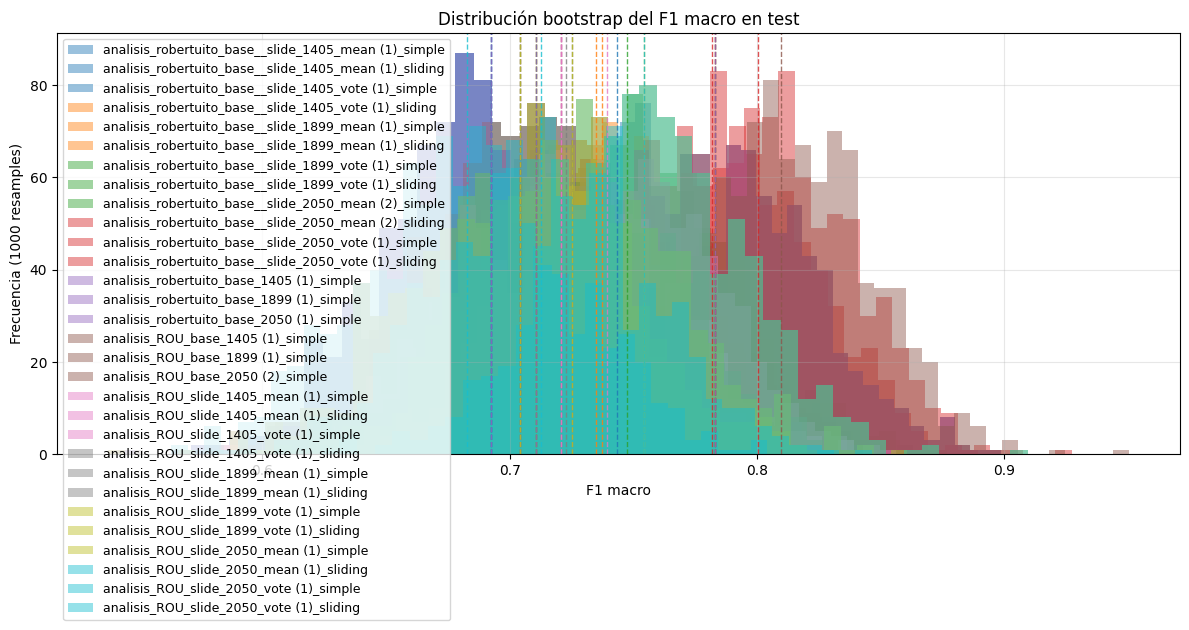

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(12, 6))
colores = plt.cm.tab10(np.linspace(0, 1, max(len(resultados), 3)))

for (nombre, res), color in zip(resultados.items(), colores):
    plt.hist(res['scores'], bins=40, alpha=0.45, label=nombre, color=color)
    plt.axvline(res['f1_mean'], color=color, linestyle='--', linewidth=1, alpha=0.8)

plt.xlabel('F1 macro')
plt.ylabel('Frecuencia (1000 resamples)')
plt.title('Distribución bootstrap del F1 macro en test')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bootstrap_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('bootstrap_distribucion.png')

## 8. Bootstrap pareado entre pares de configuraciones

Para cada par, calcula la distribución de la diferencia F1(A) − F1(B) sobre los mismos resamples.
Si el IC 95% de la diferencia cruza el cero, los modelos no son estadísticamente distinguibles.

In [ ]:
def bootstrap_diff(y_true, y_pred_a, y_pred_b, n_iterations=1000, seed=1899):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true)
    y_pred_a = np.array(y_pred_a)
    y_pred_b = np.array(y_pred_b)
    n = len(y_true)

    diffs = []
    for _ in range(n_iterations):
        idx = rng.integers(0, n, size=n)
        f1_a = f1_score(y_true[idx], y_pred_a[idx], average='macro', zero_division=0)
        f1_b = f1_score(y_true[idx], y_pred_b[idx], average='macro', zero_division=0)
        diffs.append(f1_a - f1_b)

    diffs = np.array(diffs)
    p_val = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    ci_low = np.percentile(diffs, 2.5)
    ci_high = np.percentile(diffs, 97.5)
    return {
        'mean_diff': diffs.mean(),
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p_value': p_val,
        'significant': not (ci_low < 0 < ci_high),
        'diffs': diffs
    }

In [ ]:
if len(configs) < 2:
    print("Se necesitan al menos 2 configuraciones para comparaciones pareadas.")
else:
    comparaciones = []

    for nombre_a, nombre_b in combinations(configs.keys(), 2):
        y_true_a, y_pred_a = configs[nombre_a]
        y_true_b, y_pred_b = configs[nombre_b]

        if not np.array_equal(y_true_a, y_true_b):
            print(f"Advertencia - {nombre_a} vs {nombre_b}: y_true no coincide, saltando")
            continue

        res = bootstrap_diff(y_true_a, y_pred_a, y_pred_b)
        comparaciones.append({
            'Modelo A': nombre_a,
            'Modelo B': nombre_b,
            'Dif. media': f"{res['mean_diff']:+.4f}",
            'IC 95%': f"[{res['ci_low']:+.3f}, {res['ci_high']:+.3f}]",
            'p-value': f"{res['p_value']:.3f}",
            'Significativo': 'SI' if res['significant'] else 'NO'
        })

    df_comp = pd.DataFrame(comparaciones)
    print(df_comp.to_string(index=False))
    df_comp.to_csv('bootstrap_comparaciones.csv', index=False)
    files.download('bootstrap_comparaciones.csv')

Advertencia - analisis_robertuito_base__slide_1405_mean (1)_simple vs analisis_robertuito_base__slide_1899_mean (1)_simple: y_true no coincide, saltando
Advertencia - analisis_robertuito_base__slide_1405_mean (1)_simple vs analisis_robertuito_base__slide_1899_mean (1)_sliding: y_true no coincide, saltando
Advertencia - analisis_robertuito_base__slide_1405_mean (1)_simple vs analisis_robertuito_base__slide_1899_vote (1)_simple: y_true no coincide, saltando
Advertencia - analisis_robertuito_base__slide_1405_mean (1)_simple vs analisis_robertuito_base__slide_1899_vote (1)_sliding: y_true no coincide, saltando
Advertencia - analisis_robertuito_base__slide_1405_mean (1)_simple vs analisis_robertuito_base__slide_2050_mean (2)_simple: y_true no coincide, saltando
Advertencia - analisis_robertuito_base__slide_1405_mean (1)_simple vs analisis_robertuito_base__slide_2050_mean (2)_sliding: y_true no coincide, saltando
Advertencia - analisis_robertuito_base__slide_1405_mean (1)_simple vs analisis_

KeyboardInterrupt: 

## 9. Análisis por clase del mejor modelo

Permite ver si las diferencias de rendimiento se concentran en una clase específica.

In [ ]:
def bootstrap_f1_per_class(y_true, y_pred, n_iterations=1000, seed=1899):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)
    classes = sorted(np.unique(y_true))

    scores_per_class = {c: [] for c in classes}

    for _ in range(n_iterations):
        idx = rng.integers(0, n, size=n)
        f1s = f1_score(y_true[idx], y_pred[idx], labels=classes, average=None, zero_division=0)
        for c, f1 in zip(classes, f1s):
            scores_per_class[c].append(f1)

    return {c: np.array(scores_per_class[c]) for c in classes}

In [ ]:
# Identificar el mejor modelo según F1 puntual
nombre_mejor = max(resultados.keys(), key=lambda k: resultados[k]['f1_point'])
print(f"Mejor configuración según F1 puntual: {nombre_mejor}")
print(f"F1 macro puntual: {resultados[nombre_mejor]['f1_point']:.4f}")
print()

y_true, y_pred = configs[nombre_mejor]
per_class = bootstrap_f1_per_class(y_true, y_pred)

print(f"Análisis por clase (bootstrap 1000 iteraciones):")
print(f"{'Clase':<10} {'F1 media':<12} {'IC 95%':<25}")
print("-" * 50)
for clase, scores in per_class.items():
    ci_low = np.percentile(scores, 2.5)
    ci_high = np.percentile(scores, 97.5)
    print(f"{clase:<10} {scores.mean():.3f}        [{ci_low:.3f}, {ci_high:.3f}]")

print()
print("Classification report puntual:")
print(classification_report(y_true, y_pred, zero_division=0))

Mejor configuración según F1 puntual: analisis_ROU_base_2050 (2)_simple
F1 macro puntual: 0.8118

Análisis por clase (bootstrap 1000 iteraciones):
Clase      F1 media     IC 95%                   
--------------------------------------------------
N          0.781        [0.685, 0.867]
Neu        0.847        [0.762, 0.919]
P          0.802        [0.688, 0.900]

Classification report puntual:
              precision    recall  f1-score   support

           N       0.74      0.83      0.78        41
         Neu       0.85      0.85      0.85        46
           P       0.87      0.75      0.81        36

    accuracy                           0.81       123
   macro avg       0.82      0.81      0.81       123
weighted avg       0.82      0.81      0.81       123



## 10. Visualizar diferencia entre dos modelos específicos

Útil para la defensa: muestra visualmente si dos configuraciones son estadísticamente distinguibles.

Configuraciones disponibles:
  [0] analisis_robertuito_base__slide_1405_mean (1)_simple
  [1] analisis_robertuito_base__slide_1405_mean (1)_sliding
  [2] analisis_robertuito_base__slide_1405_vote (1)_simple
  [3] analisis_robertuito_base__slide_1405_vote (1)_sliding
  [4] analisis_robertuito_base__slide_1899_mean (1)_simple
  [5] analisis_robertuito_base__slide_1899_mean (1)_sliding
  [6] analisis_robertuito_base__slide_1899_vote (1)_simple
  [7] analisis_robertuito_base__slide_1899_vote (1)_sliding
  [8] analisis_robertuito_base__slide_2050_mean (2)_simple
  [9] analisis_robertuito_base__slide_2050_mean (2)_sliding
  [10] analisis_robertuito_base__slide_2050_vote (1)_simple
  [11] analisis_robertuito_base__slide_2050_vote (1)_sliding
  [12] analisis_robertuito_base_1405 (1)_simple
  [13] analisis_robertuito_base_1899 (1)_simple
  [14] analisis_robertuito_base_2050 (1)_simple
  [15] analisis_ROU_base_1405 (1)_simple
  [16] analisis_ROU_base_1899 (1)_simple
  [17] analisis_ROU_base_2050

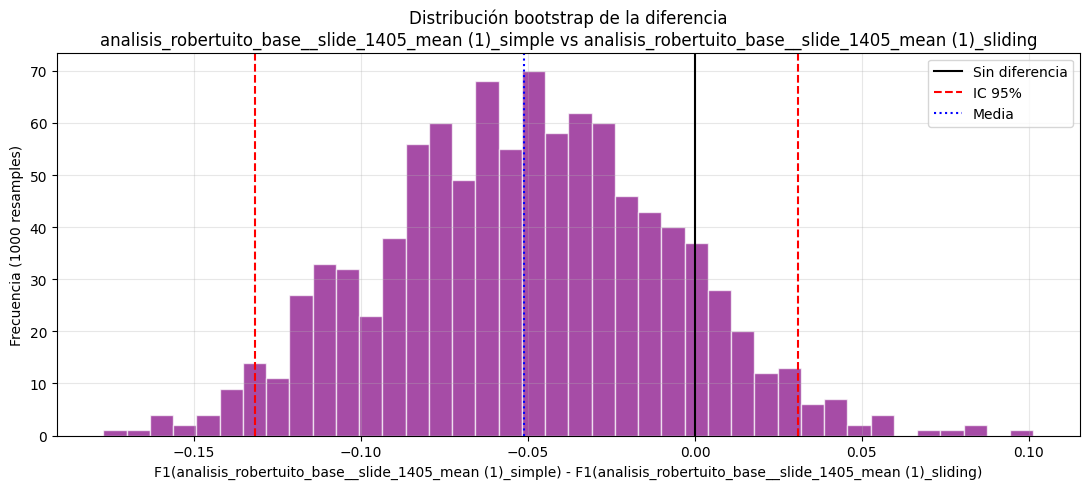


Resumen:
  Diferencia media: -0.0511
  IC 95%: [-0.132, +0.031]
  -> El IC cruza el cero: NO significativa


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Editar estos nombres con dos configuraciones que quieras comparar visualmente
# Por ejemplo: el mejor ROUBERTa vs el mejor RoBERTuito

nombres_disponibles = list(configs.keys())
print("Configuraciones disponibles:")
for i, n in enumerate(nombres_disponibles):
    print(f"  [{i}] {n}")

# Cambiá estos índices según lo que quieras comparar
idx_a = 0
idx_b = 1 if len(nombres_disponibles) > 1 else 0

nombre_a = nombres_disponibles[idx_a]
nombre_b = nombres_disponibles[idx_b]

if nombre_a != nombre_b:
    y_true_a, y_pred_a = configs[nombre_a]
    y_true_b, y_pred_b = configs[nombre_b]

    res_diff = bootstrap_diff(y_true_a, y_pred_a, y_pred_b)

    plt.figure(figsize=(11, 5))
    plt.hist(res_diff['diffs'], bins=40, color='purple', alpha=0.7, edgecolor='white')
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5, label='Sin diferencia')
    plt.axvline(res_diff['ci_low'], color='red', linestyle='--', linewidth=1.5, label='IC 95%')
    plt.axvline(res_diff['ci_high'], color='red', linestyle='--', linewidth=1.5)
    plt.axvline(res_diff['mean_diff'], color='blue', linestyle=':', linewidth=1.5, label='Media')
    plt.xlabel(f'F1({nombre_a}) - F1({nombre_b})')
    plt.ylabel('Frecuencia (1000 resamples)')
    plt.title(f'Distribución bootstrap de la diferencia\n{nombre_a} vs {nombre_b}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('bootstrap_diferencia.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nResumen:")
    print(f"  Diferencia media: {res_diff['mean_diff']:+.4f}")
    print(f"  IC 95%: [{res_diff['ci_low']:+.3f}, {res_diff['ci_high']:+.3f}]")
    if res_diff['significant']:
        print(f"  -> Diferencia ESTADISTICAMENTE SIGNIFICATIVA al 95%")
    else:
        print(f"  -> El IC cruza el cero: NO significativa")
    files.download('bootstrap_diferencia.png')

## 11. Guardar todos los outputs

Descarga todos los CSVs e imágenes generadas.

In [ ]:
import os

print("Archivos generados en este notebook:")
for f in os.listdir('.'):
    if f.endswith(('.csv', '.png')):
        size = os.path.getsize(f)
        print(f"  - {f} ({size} bytes)")

Archivos generados en este notebook:
  - bootstrap_diferencia.png (78147 bytes)
  - bootstrap_resultados.csv (2672 bytes)
  - bootstrap_distribucion.png (319720 bytes)
  - bootstrap_comparaciones.csv (424 bytes)


In [ ]:
# Re-generar df_comp con TODAS las configuraciones actuales
from itertools import combinations

comparaciones = []

for nombre_a, nombre_b in combinations(configs.keys(), 2):
    y_true_a, y_pred_a = configs[nombre_a]
    y_true_b, y_pred_b = configs[nombre_b]

    # Solo comparar si tienen el mismo y_true
    if len(y_true_a) != len(y_true_b):
        continue
    if not np.array_equal(y_true_a, y_true_b):
        continue

    res = bootstrap_diff(y_true_a, y_pred_a, y_pred_b)
    comparaciones.append({
        'Modelo A': nombre_a,
        'Modelo B': nombre_b,
        'Dif. media': f"{res['mean_diff']:+.4f}",
        'IC 95%': f"[{res['ci_low']:+.3f}, {res['ci_high']:+.3f}]",
        'p-value': f"{res['p_value']:.3f}",
        'Significativo': 'SI' if res['significant'] else 'NO'
    })

df_comp = pd.DataFrame(comparaciones)
print(f"Total de comparaciones pareadas válidas: {len(df_comp)}")
print()
print(f"Primeras 10 filas:")
print(df_comp.head(10).to_string())

df_comp.to_csv('bootstrap_comparaciones.csv', index=False)

Total de comparaciones pareadas válidas: 135

Primeras 10 filas:
                                                Modelo A                                               Modelo B Dif. media            IC 95% p-value Significativo
0   analisis_robertuito_base__slide_1405_mean (1)_simple  analisis_robertuito_base__slide_1405_mean (1)_sliding    -0.0511  [-0.132, +0.031]   0.224            NO
1   analisis_robertuito_base__slide_1405_mean (1)_simple   analisis_robertuito_base__slide_1405_vote (1)_simple    +0.0000  [+0.000, +0.000]   2.000            SI
2   analisis_robertuito_base__slide_1405_mean (1)_simple  analisis_robertuito_base__slide_1405_vote (1)_sliding    -0.0423  [-0.122, +0.042]   0.322            NO
3   analisis_robertuito_base__slide_1405_mean (1)_simple               analisis_robertuito_base_1405 (1)_simple    +0.0000  [+0.000, +0.000]   2.000            SI
4   analisis_robertuito_base__slide_1405_mean (1)_simple                      analisis_ROU_base_1405 (1)_simple    -0.02

In [ ]:
# Solo comparaciones dentro del mismo seed (pareadas válidas)
comparaciones_validas = [
    ({'modelo': 'ROU_base', 'seed': '2050', 'esquema': '_simple'},
     {'modelo': 'robertuito_base__slide', 'seed': '2050_mean', 'esquema': '_sliding'},
     'PICO: ROUBERTa simple 2050 vs RoBERTuito sliding mean 2050'),

    ({'modelo': 'ROU_slide', 'seed': '2050_mean', 'esquema': '_sliding'},
     {'modelo': 'robertuito_base__slide', 'seed': '2050_mean', 'esquema': '_sliding'},
     'Sliding mean 2050: ROUBERTa vs RoBERTuito'),

    ({'modelo': 'ROU_base', 'seed': '2050', 'esquema': '_simple'},
     {'modelo': 'ROU_slide', 'seed': '2050_mean', 'esquema': '_sliding'},
     'ROUBERTa 2050: simple vs sliding mean'),

    ({'modelo': 'robertuito_base', 'seed': '2050', 'esquema': '_simple'},
     {'modelo': 'robertuito_base__slide', 'seed': '2050_mean', 'esquema': '_sliding'},
     'RoBERTuito 2050: simple vs sliding mean'),
]

print("=" * 100)
print("COMPARACIONES PAREADAS VÁLIDAS (mismo seed)")
print("=" * 100)

for patrones_a, patrones_b, desc in comparaciones_validas:
    nombre_a = buscar_config(patrones_a['modelo'], patrones_a['seed'], patrones_a['esquema'])
    nombre_b = buscar_config(patrones_b['modelo'], patrones_b['seed'], patrones_b['esquema'])

    if nombre_a is None or nombre_b is None:
        print(f"\n{desc}")
        print(f"  No encontrado. A={nombre_a}, B={nombre_b}")
        continue

    fila = df_comp[
        ((df_comp['Modelo A'] == nombre_a) & (df_comp['Modelo B'] == nombre_b)) |
        ((df_comp['Modelo A'] == nombre_b) & (df_comp['Modelo B'] == nombre_a))
    ]

    if len(fila) > 0:
        r = fila.iloc[0]
        print(f"\n{desc}")
        print(f"  A: {nombre_a}")
        print(f"  B: {nombre_b}")
        print(f"  Dif. media: {r['Dif. media']}   IC 95%: {r['IC 95%']}")
        print(f"  p-value: {r['p-value']}   Significativo: {r['Significativo']}")
    else:
        print(f"\n{desc}")
        print(f"  A y B encontrados pero y_true distinto (splits diferentes)")

COMPARACIONES PAREADAS VÁLIDAS (mismo seed)

PICO: ROUBERTa simple 2050 vs RoBERTuito sliding mean 2050
  A: analisis_ROU_base_2050 (2)_simple
  B: analisis_robertuito_base__slide_2050_mean (2)_sliding
  Dif. media: -0.0093   IC 95%: [-0.075, +0.059]
  p-value: 0.798   Significativo: NO

Sliding mean 2050: ROUBERTa vs RoBERTuito
  A: analisis_ROU_slide_2050_mean (1)_sliding
  B: analisis_robertuito_base__slide_2050_mean (2)_sliding
  Dif. media: +0.0875   IC 95%: [+0.019, +0.159]
  p-value: 0.014   Significativo: SI

ROUBERTa 2050: simple vs sliding mean
  A: analisis_ROU_base_2050 (2)_simple
  B: analisis_ROU_slide_2050_mean (1)_sliding
  Dif. media: +0.0969   IC 95%: [+0.025, +0.171]
  p-value: 0.002   Significativo: SI

RoBERTuito 2050: simple vs sliding mean
  A: analisis_robertuito_base__slide_2050_mean (2)_simple
  B: analisis_robertuito_base__slide_2050_mean (2)_sliding
  Dif. media: -0.0173   IC 95%: [-0.079, +0.044]
  p-value: 0.588   Significativo: NO


In [ ]:
# Verificación de signo: F1 puntual de A menos F1 puntual de B
f1_A_punt = 0.7164  # ROUBERTa slide 2050 mean sliding
f1_B_punt = 0.8020  # RoBERTuito slide 2050 mean sliding
print(f"F1(A) - F1(B) = {f1_A_punt - f1_B_punt:.4f}")
# Si no coincide con lo que reportó bootstrap_diff, el signo está invertido

F1(A) - F1(B) = -0.0856


In [ ]:
# Ver qué hay realmente en df_comp
print(f"Total de comparaciones en df_comp: {len(df_comp)}")
print()

# Filtrar solo las que involucran ROU_base_2050
filas_rou_2050 = df_comp[
    df_comp['Modelo A'].str.contains('ROU_base_2050', na=False) |
    df_comp['Modelo B'].str.contains('ROU_base_2050', na=False)
]
print(f"Comparaciones que involucran ROU_base_2050: {len(filas_rou_2050)}")
print()
print(filas_rou_2050.to_string())

Total de comparaciones en df_comp: 3

Comparaciones que involucran ROU_base_2050: 2

                                            Modelo A                       Modelo B Dif. media            IC 95% p-value Significativo
1   analisis_robertuito_base__slide_2050_mean_simple  analisis_ROU_base_2050_simple    +0.0282  [-0.043, +0.097]   0.428            NO
2  analisis_robertuito_base__slide_2050_mean_sliding  analisis_ROU_base_2050_simple    +0.0437  [-0.029, +0.118]   0.258            NO
